# kNN classifier for breast cancer diagnosis

Dataset: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

The target variable is the diagnosis label: `B` (benign) or `M` (malignant). The predictors are 30 real-valued measurements describing cell-nuclei characteristics in digitized breast mass images.

## 1. Business understanding

In this document we develop a decision-support model that predicts whether a breast tumor is malignant or benign from diagnostic measurements, so clinicians can identify high-risk cases earlier and reduce missed cancer diagnoses.

The model is assessed using a hold-out validation set and standard classification metrics to determine whether it is accurate enough to be useful in a diagnosis support setting.

## 2. Data understanding

## Dataset variables

This dataset has 32 columns: `id`, `diagnosis`, and 30 measurement features. The features describe tumor shape and texture, including `radius`, `texture`, `perimeter`, `area`, `smoothness`, `compactness`, `concavity`, `concave_points`, `symmetry`, and `fractal_dimension`, with values recorded as mean, standard error, and worst-case values. `diagnosis` is the target label (`M` = malignant, `B` = benign).

Below the printed output in a dataset



In [34]:
from pathlib import Path
import pandas as pd

feature_names = [
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se",
    "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv(
    "data/breast+cancer+wisconsin+diagnostic/wdbc.data",
    header=None,
    names=["id", "diagnosis", *feature_names],
)

print("Dataset shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))
print("\nDiagnosis distribution:")
print(df["diagnosis"].value_counts())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (569, 32)

First 10 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   
5    843786         M        12.45         15.70           82.57      477.1   
6    844359         M        18.25         19.98          119.60     1040.0   
7  84458202         M        13.71         20.83           90.20      577.9   
8    844981         M        13.00         21.82           87.50      519.8   
9  84501001         M        12.46         24.04           83.97      475.9   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0

## 3. Data preparation

The input variables in this dataset are measured on very different scales (for example, `area_mean` ranges up to several thousand, while `smoothness_mean` is always below 1). Since k-NN relies on Euclidean distance between samples, features with larger numerical ranges would dominate the distance calculation and effectively drown out the influence of the smaller-scale features. To give every feature a roughly equal say in the distance calculation, we apply **standardization**, transforming each feature to have a mean of 0 and a standard deviation of 1.

In order to fairly evaluate the classifier later on, we need to set aside part of the data that the model never sees during training. This is the **hold-out validation** technique: the dataset is split into a **training set**, used to build the model, and a **test set**, used only afterwards to assess how well the model generalizes to new, unseen samples. Here we reserve 20% of the samples for testing and use the remaining 80% for training.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate input variables (X) and target variable (y)
X = df[feature_names]
y = df["diagnosis"]

# Hold-out split: 80% training data, 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Standardize the input variables
# The scaler is fit on the training data only, then used to transform both sets
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe()

Training set shape: (455, 30)
Test set shape: (114, 30)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02
mean,-1.737316e-16,3.904081e-16,4.704418e-16,-1.171224e-16,7.242070e-16,-5.075305e-17,-4.489693e-17,2.928061e-17,2.342449e-17,3.669836e-16,1.678755e-16,-8.979386e-17,-2.498612e-16,1.444510e-16,-1.561632e-16,-1.561632e-17,4.684897e-17,-1.405469e-16,8.588978e-17,-2.342449e-17,-3.962642e-16,2.186285e-16,-2.986622e-16,-1.561632e-17,-1.522592e-16,-1.132183e-16,-4.489693e-17,3.025663e-17,-4.841060e-16,3.006142e-16
std,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00
min,-2.009730e+00,-2.265011e+00,-1.961360e+00,-1.433461e+00,-2.342455e+00,-1.568307e+00,-1.092835e+00,-1.236420e+00,-2.733834e+00,-1.791603e+00,-1.033890e+00,-1.554603e+00,-1.015930e+00,-7.133542e-01,-1.817396e+00,-1.310530e+00,-1.010196e+00,-1.860867e+00,-1.511145e+00,-1.092098e+00,-1.720204e+00,-2.286387e+00,-1.682868e+00,-1.212587e+00,-2.596976e+00,-1.442492e+00,-1.298977e+00,-1.729670e+00,-2.141576e+00,-1.602524e+00
25%,-6.869865e-01,-7.192578e-01,-6.877646e-01,-6.643427e-01,-7.599676e-01,-7.446452e-01,-7.311067e-01,-7.398554e-01,-7.042022e-01,-7.295506e-01,-6.124852e-01,-6.816724e-01,-6.123058e-01,-4.846603e-01,-6.380051e-01,-6.991575e-01,-5.358218e-01,-6.582118e-01,-6.518979e-01,-5.882379e-01,-6.805052e-01,-7.269867e-01,-6.949785e-01,-6.436573e-01,-7.475060e-01,-6.811748e-01,-7.355618e-01,-7.700379e-01,-6.377821e-01,-7.030095e-01
50%,-2.310610e-01,-1.207886e-01,-2.444667e-01,-3.143644e-01,-5.267576e-02,-2.145711e-01,-3.649669e-01,-3.954004e-01,-5.783428e-02,-2.031921e-01,-2.890574e-01,-1.429786e-01,-2.836539e-01,-3.395152e-01,-2.224300e-01,-2.932991e-01,-1.942788e-01,-1.242557e-01,-2.079996e-01,-2.415417e-01,-2.924054e-01,-6.996374e-02,-2.990905e-01,-3.561409e-01,-4.191078e-02,-2.454053e-01,-2.141609e-01,-2.170230e-01,-1.439281e-01,-2.222582e-01
75%,4.947835e-01,5.628428e-01,4.975359e-01,3.775369e-01,6.231343e-01,4.923801e-01,5.271006e-01,6.321626e-01,5.034376e-01,5.249492e-01,2.546464e-01,4.669490e-01,2.225267e-01,8.505718e-02,4.012832e-01,3.818060e-01,2.679480e-01,4.487783e-01,3.105843e-01,2.787879e-01,5.787764e-01,7.072664e-01,5.606441e-01,3.987080e-01,6.189186e-01,5.218523e-01,5.217957e-01,6.980537e-01,4.340876e-01,4.386715e-01
max,3.900239e+00,4.634299e+00,3.899731e+00,5.114742e+00,4.715773e+00,4.485809e+00,4.137033e+00,3.838961e+00,4.435961e+00,4.987148e+00,8.493000e+00,6.646884e+00,8.991216e+00,1.036439e+01,8.499034e+00,4.605403e+00,1.148413e+01,6.542039e+00,7.049767e+00,9.917437e+00,4.021630e+00,3.891934e+00,4.198771e+00,5.782013e+00,3.859114e+00,5.071677e+00,4.611335e+00,2.628551e+00,5.914120e+00,6.798089e+00


## 4. Modeling

We apply the k-NN classifier to model the relationship between the standardized cell-nuclei measurements and the diagnosis label.  The hyperparameter k is selected by experimenting with several values and comparing their validation performance.

The candidate values used in this notebook are `k = 1, 3, 5, 7, 9, 11`.

k =  1: validation accuracy = 0.9298
k =  3: validation accuracy = 0.9386
k =  5: validation accuracy = 0.9561
k =  7: validation accuracy = 0.9561
k =  9: validation accuracy = 0.9474
k = 11: validation accuracy = 0.9474


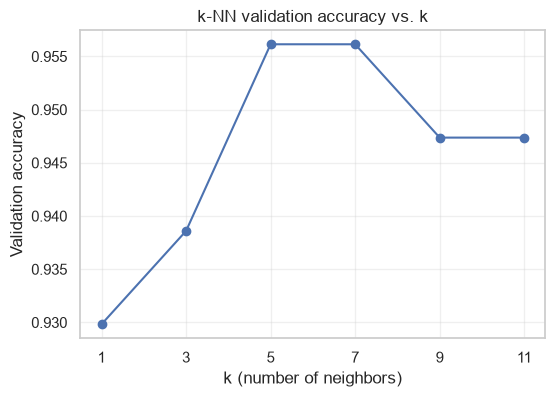

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Candidate values of k to experiment with
k_values = [1, 3, 5, 7, 9, 11]
models = {}
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    models[k] = model

    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"k = {k:>2}: validation accuracy = {acc:.4f}")

# Visualize how accuracy changes with k
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_values, accuracies, marker='o')
ax.set(xlabel="k (number of neighbors)", ylabel="Validation accuracy",
       title="k-NN validation accuracy vs. k")
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3)

plt.show()

## 5. Evaluation

Based on the validation accuracies, we select the best-performing value of k and evaluate that final model in detail on the held-out test set.

We present the confusion matrix along with the three standard evaluation metrics: accuracy, precision, and recall. Since this is a binary classification problem, we treat malignant (`M`) as the positive class. In a medical diagnosis context, the cost of the two types of errors is not equal: a **false negative** (a malignant tumor predicted as benign) means a cancer case goes undetected, which is far more dangerous than a **false positive** (a benign tumor predicted as malignant, which would likely just prompt further, unnecessary testing). For this reason, **recall on the malignant class** is arguably the single most important metric here, even more so than overall accuracy.

Best k selected: 5 (validation accuracy = 0.9561)


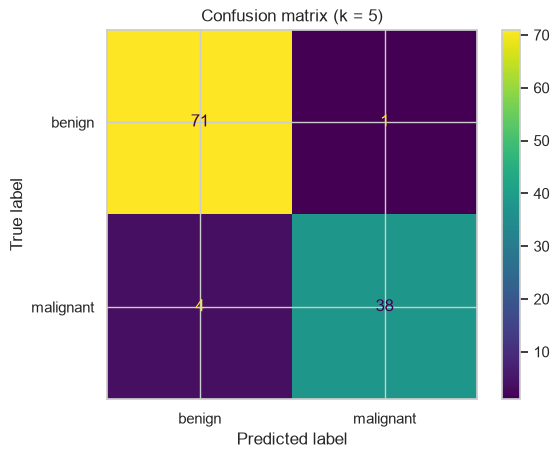

Accuracy:  0.9561
Precision (malignant): 0.9744
Recall (malignant):    0.9048


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score

# Select the best-performing k based on validation accuracy from section 4
best_k = k_values[accuracies.index(max(accuracies))]
best_model = models[best_k]

print(f"Best k selected: {best_k} (validation accuracy = {max(accuracies):.4f})")

# Generate predictions on the test set using the chosen model
y_pred = best_model.predict(X_test_scaled)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['B', 'M'])
cmd = ConfusionMatrixDisplay(cm, display_labels=['benign', 'malignant'])
cmd.plot()
plt.title(f"Confusion matrix (k = {best_k})")
plt.show()

# Evaluation metrics
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='M')
recall = recall_score(y_test, y_pred, pos_label='M')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision (malignant): {precision:.4f}")
print(f"Recall (malignant):    {recall:.4f}")

6. Deployment

The results show that the kNN classifier can separate malignant and benign diagnoses well when the training and test data are standardized and a suitable k is selected. In this dataset, the model achieves high accuracy and a strong recall for malignant cases, which is especially important in a medical screening context because false negatives can be costly.

The choice of k affects the bias-variance trade-off: small values create a model that adapts too much to local noise, whereas larger values smooth the decision boundary.